# 01 — Logistic Regression

## Theory

Logistic Regression is a **linear model for classification** (despite the
name). Instead of predicting the class directly, it models the
**log-odds** of the positive class as a linear function of the features:

$$\text{logit}(p) = \ln\frac{p}{1-p} = w_0 + w_1x_1 + \dots + w_nx_n$$

Solving for `p` gives the **sigmoid** function, which squashes the linear
score into a valid probability between 0 and 1:

$$p = P(y=1 \mid x) = \sigma(w \cdot x) = \frac{1}{1 + e^{-(w \cdot x)}}$$

**Training** finds the weights `w` that maximize the likelihood of the
observed labels, equivalently minimizing the **log-loss** (binary
cross-entropy):

$$J(w) = -\frac{1}{N}\sum_{i=1}^{N}\Big[y_i \ln p_i + (1-y_i)\ln(1-p_i)\Big]$$

This is a convex function, so gradient descent (or the solvers scikit-learn
uses under the hood) reliably converges to the global minimum.

**Assumptions & properties:**
- Assumes a roughly **linear decision boundary** in the (log-odds) feature
  space — it cannot learn curved boundaries on its own without engineered
  features.
- Coefficients are interpretable as **log-odds ratios**: `exp(w_i)` is the
  multiplicative change in the odds of the positive class per unit increase
  in feature `i`, holding others fixed.
- Sensitive to feature **scale** — the raw coefficient sizes (and therefore
  regularization, which penalizes coefficient size) aren't comparable across
  features unless the features are standardized first.
- Fast to train, cheap to predict, and a strong, well-calibrated baseline —
  it's usually the first model worth trying on a new tabular problem.


In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Harmless artifact of macOS's Accelerate BLAS backend on certain zero-valued
# matmul inputs (values stay finite and correct) -- not a real numerical issue.
warnings.filterwarnings("ignore", message=".*encountered in matmul.*", category=RuntimeWarning)

sns.set_theme(style="whitegrid")

DATA_PATH = "../data/german_credit_data.csv"

df = pd.read_csv(DATA_PATH, index_col=0)

# A blank in either account column means the applicant holds no such account
# -- real information, not a missing measurement -- so it becomes its own level.
df[["Saving accounts", "Checking account"]] = df[["Saving accounts", "Checking account"]].fillna("none")

# Binary target: 1 = "bad" credit risk, i.e. the borrower defaulted. See
# 00_data_exploration_and_preprocessing.ipynb for why "bad" is the positive
# class, why the blanks become "none", and how the categoricals are encoded.
y = (df["Risk"] == "bad").astype(int)

CATEGORICAL = ["Sex", "Housing", "Saving accounts", "Checking account", "Purpose"]
X = pd.get_dummies(df.drop(columns=["Risk"]), columns=CATEGORICAL, drop_first=True).astype(float)

# Same split (test_size, random_state, stratify) is used in every notebook
# in this folder so that results are directly comparable across algorithms.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print("Train class balance:")
print(y_train.value_counts(normalize=True).rename("proportion"))


Train shape: (800, 21), Test shape: (200, 21)
Train class balance:
Risk
0    0.7
1    0.3
Name: proportion, dtype: float64


## Feature scaling

Logistic Regression's regularization penalty acts on the raw coefficient
values, so a feature on a larger numeric scale gets penalized unfairly less
per unit of "importance" than a feature on a small scale. We standardize
every feature to zero mean / unit variance (`StandardScaler`), **fitting
only on the training data** to avoid leaking test-set statistics.


In [2]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), columns=X_test.columns, index=X_test.index
)


## Baseline model

The baseline is scikit-learn's default `LogisticRegression` — L2 penalty,
`C=1.0` — fit on the scaled features. Every later change in this notebook is
measured against it.


In [3]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay,
)


def evaluate(model, X_te, y_te, y_pred=None, y_proba=None, label="model"):
    """Print the standard metric set and plot a confusion matrix."""
    if y_pred is None:
        y_pred = model.predict(X_te)
    print(f"--- {label} ---")
    print(classification_report(y_te, y_pred, target_names=["good risk", "bad risk"]))
    if y_proba is not None:
        print(f"ROC-AUC: {roc_auc_score(y_te, y_proba):.3f}")
    ConfusionMatrixDisplay.from_predictions(
        y_te, y_pred, display_labels=["good", "bad"], cmap="Blues"
    )
    plt.title(f"Confusion matrix — {label}")
    plt.show()


--- Logistic Regression (baseline) ---
              precision    recall  f1-score   support

   good risk       0.78      0.89      0.83       140
    bad risk       0.62      0.40      0.48        60

    accuracy                           0.74       200
   macro avg       0.70      0.65      0.66       200
weighted avg       0.73      0.74      0.73       200

ROC-AUC: 0.757


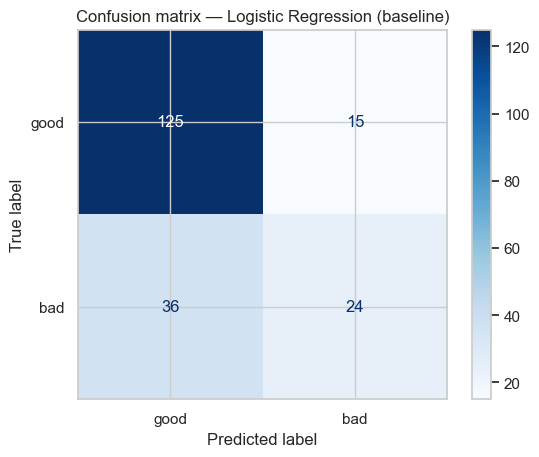

In [4]:
from sklearn.linear_model import LogisticRegression

baseline = LogisticRegression(max_iter=5000, random_state=42)
baseline.fit(X_train_scaled, y_train)

y_pred = baseline.predict(X_test_scaled)
y_proba = baseline.predict_proba(X_test_scaled)[:, 1]
evaluate(baseline, X_test_scaled, y_test, y_pred, y_proba, label="Logistic Regression (baseline)")


## Regularization — L1 and L2

Without regularization, Logistic Regression can push coefficients to large
magnitudes to fit noise in the training data, especially with correlated
features. Regularization adds a penalty on the coefficients to the loss
function, trading a bit of training-set fit for better generalization:

- **L2 (Ridge)** penalty: adds $\lambda \sum w_i^2$. Shrinks all
  coefficients smoothly toward zero but rarely to *exactly* zero — keeps
  every feature, just dampened.
- **L1 (Lasso)** penalty: adds $\lambda \sum |w_i|$. Its penalty has
  "corners" at zero, which pushes unimportant coefficients to **exactly
  zero** — this performs implicit **feature selection**.

Scikit-learn parameterizes strength with `C = 1/\lambda` — confusingly,
**smaller `C` means stronger regularization**, and larger `C` means weaker
regularization (closer to the unregularized model).


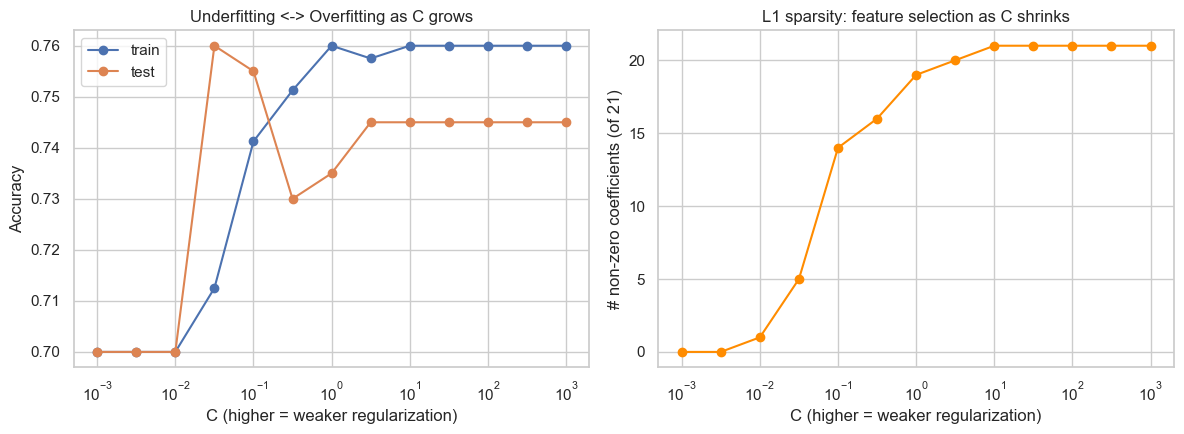

In [5]:
from sklearn.metrics import accuracy_score

Cs = np.logspace(-3, 3, 13)
train_acc, test_acc, n_nonzero = [], [], []

for C in Cs:
    lr = LogisticRegression(C=C, penalty="l1", solver="liblinear", max_iter=5000, random_state=42)
    lr.fit(X_train_scaled, y_train)
    train_acc.append(accuracy_score(y_train, lr.predict(X_train_scaled)))
    test_acc.append(accuracy_score(y_test, lr.predict(X_test_scaled)))
    n_nonzero.append(np.sum(lr.coef_ != 0))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(Cs, train_acc, marker="o", label="train")
axes[0].plot(Cs, test_acc, marker="o", label="test")
axes[0].set_xscale("log")
axes[0].set_xlabel("C (higher = weaker regularization)")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Underfitting <-> Overfitting as C grows")
axes[0].legend()

axes[1].plot(Cs, n_nonzero, marker="o", color="darkorange")
axes[1].set_xscale("log")
axes[1].set_xlabel("C (higher = weaker regularization)")
axes[1].set_ylabel(f"# non-zero coefficients (of {X_train.shape[1]})")
axes[1].set_title("L1 sparsity: feature selection as C shrinks")
plt.tight_layout()
plt.show()


The sweep behaves as the penalty predicts. Below `C` of about 0.01 the L1
penalty has zeroed nearly every coefficient and the model falls back to
near-majority-class predictions; as `C` grows, coefficients re-enter and both
train and test accuracy climb; past the middle of the range train accuracy
keeps creeping up while test accuracy flattens. The search below lands at
`C=0.1`, in that middle band rather than at either extreme.


## Hyperparameter search

Hyperparameters (`C`, `k`, `max_depth`, ...) are fixed before training, unlike
the weights the fit itself learns. All of them are selected here with **5-fold
cross-validation on the training set only**, scored on ROC-AUC: every
candidate setting is fit on four folds and scored on the fifth, rotating
through all five, and the averaged score decides the winner. The test set
takes no part in the search, which is what keeps the final numbers reported
after it meaningful.

`GridSearchCV` is used where the space is small enough to enumerate
exhaustively and `RandomizedSearchCV` where it is not — sampling a fixed
number of random combinations reaches a near-equivalent setting far more
cheaply once several hyperparameters turn out to barely move the score.


Best params: {'C': np.float64(0.1), 'penalty': 'l1', 'solver': 'liblinear'}
Best CV ROC-AUC: 0.755
--- Logistic Regression (tuned) ---
              precision    recall  f1-score   support

   good risk       0.77      0.94      0.84       140
    bad risk       0.69      0.33      0.45        60

    accuracy                           0.76       200
   macro avg       0.73      0.63      0.65       200
weighted avg       0.74      0.76      0.72       200

ROC-AUC: 0.754


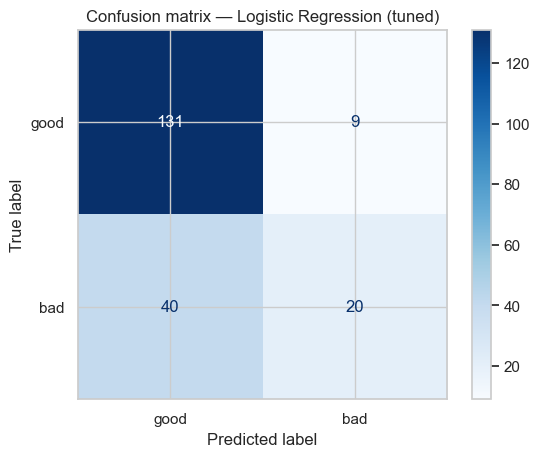

In [6]:
from sklearn.model_selection import GridSearchCV

param_grid = [
    {"penalty": ["l2"], "C": np.logspace(-3, 3, 13), "solver": ["lbfgs"]},
    {"penalty": ["l1"], "C": np.logspace(-3, 3, 13), "solver": ["liblinear"]},
]

grid = GridSearchCV(
    LogisticRegression(max_iter=5000, random_state=42),
    param_grid=param_grid, scoring="roc_auc", cv=5, n_jobs=-1,
)
grid.fit(X_train_scaled, y_train)

print("Best params:", grid.best_params_)
print(f"Best CV ROC-AUC: {grid.best_score_:.3f}")

best_lr = grid.best_estimator_
y_pred = best_lr.predict(X_test_scaled)
y_proba = best_lr.predict_proba(X_test_scaled)[:, 1]
evaluate(best_lr, X_test_scaled, y_test, y_pred, y_proba, label="Logistic Regression (tuned)")


## Decision threshold tuning

Every model in this project exposes a predicted probability `P(bad | x)` as
well as a hard label. `.predict()` converts one into the other at a fixed
cutoff of **0.5**: `P(bad) >= 0.5` becomes "bad risk".

0.5 is a library default, not a decision that belongs to this problem, and
two things make it the wrong cutoff here:

1. **Class imbalance.** Only ~30% of these applicants defaulted, so the model
   has to be unusually confident before `P(bad)` clears 0.5. The default
   cutoff quietly favours the majority "good" class and suppresses recall on
   exactly the class a lender needs to catch. (`class_weight="balanced"` is
   the other lever for this and moves roughly the same boundary, but it
   requires retraining.)
2. **Asymmetric costs.** Approving a loan that defaults costs the outstanding
   principal; declining an applicant who would have repaid costs only the
   foregone interest. Those are not the same number, which makes the cutoff a
   business parameter rather than a technicality — and moving it walks the
   model along its existing ROC / precision-recall curve without retraining
   anything.

Two reference cutoffs are computed below:

- **Youden's J** (`J = TPR - FPR`) on the ROC curve — the cutoff that
  separates the classes best when both error types are weighted equally.
- **F1-optimal** on the precision-recall curve — the cutoff that balances
  precision and recall on the positive class, the more informative of the two
  curves under this much imbalance.

> **Methodology caveat — both cutoffs below are selected on the test set,
> which is test-set leakage.**
>
> The scan maximises J / F1 over the held-out data itself, so the test set has
> informed a modelling decision and the two tuned rows are optimistic: they
> are not a clean estimate of how that cutoff would generalise. The step is
> kept because what is being recorded is the *size* of the precision/recall
> shift a cutoff can produce, not the specific threshold value.
>
> This is not how the cutoff would be set in production. There it would be
> chosen on data the model is not being judged on — a separate validation
> fold, or out-of-fold predictions from cross-validation — and then settled in
> deployment: shadow-score live applications for some days or weeks, watch the
> realised default rate against the approval rate, and adjust the cutoff by
> trial and error until it sits where the business wants it. The threshold is
> an operational dial that gets revisited, not a number frozen at training
> time.


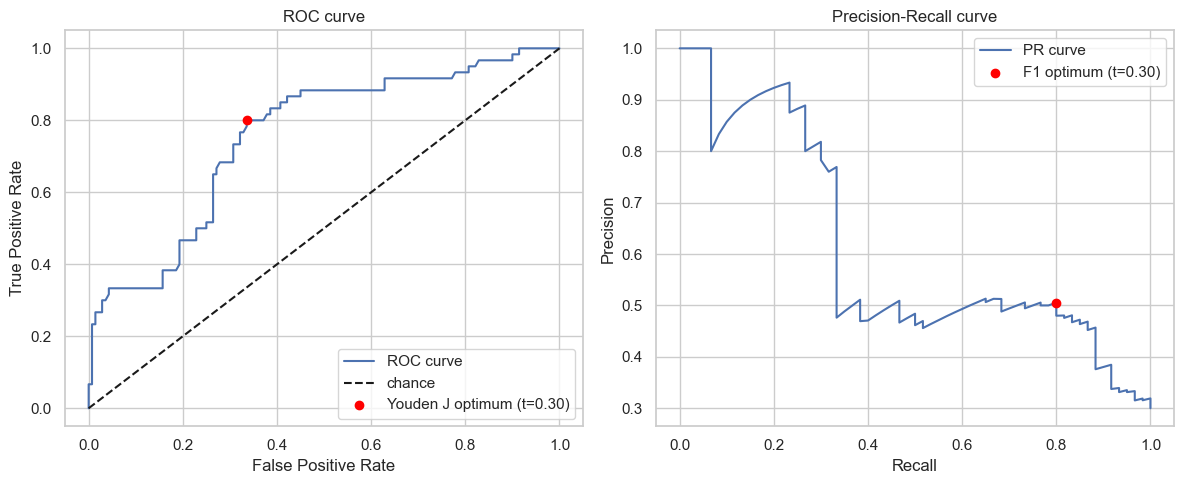

Youden's J optimal threshold: 0.298
F1-optimal threshold:         0.298


,threshold,accuracy,precision,recall,f1
default (0.5),0.500,0.755,0.689655,0.333333,0.449438
Youden's J,0.298,0.705,0.505263,0.800000,0.619355
F1-optimal,0.298,0.705,0.505263,0.800000,0.619355


In [7]:
from sklearn.metrics import roc_curve, precision_recall_curve, f1_score

y_proba_best = best_lr.predict_proba(X_test_scaled)[:, 1]

# --- ROC curve & Youden's J statistic -------------------------------------
fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba_best)
j_scores = tpr - fpr
best_j_idx = np.argmax(j_scores)
best_j_threshold = roc_thresholds[best_j_idx]

# --- Precision-Recall curve & F1-optimal threshold -------------------------
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_proba_best)
f1_scores = np.divide(
    2 * precision * recall, precision + recall,
    out=np.zeros_like(precision), where=(precision + recall) != 0
)
best_f1_idx = np.argmax(f1_scores[:-1])  # last point has no matching threshold
best_f1_threshold = pr_thresholds[best_f1_idx]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(fpr, tpr, label="ROC curve")
axes[0].plot([0, 1], [0, 1], "k--", label="chance")
axes[0].scatter(fpr[best_j_idx], tpr[best_j_idx], color="red", zorder=5,
                 label=f"Youden J optimum (t={best_j_threshold:.2f})")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC curve")
axes[0].legend()

axes[1].plot(recall, precision, label="PR curve")
axes[1].scatter(recall[best_f1_idx], precision[best_f1_idx], color="red", zorder=5,
                 label=f"F1 optimum (t={best_f1_threshold:.2f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall curve")
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"Youden's J optimal threshold: {best_j_threshold:.3f}")
print(f"F1-optimal threshold:         {best_f1_threshold:.3f}")


def metrics_at_threshold(y_true, proba, threshold):
    preds = (proba >= threshold).astype(int)
    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, preds),
        "precision": precision_score(y_true, preds, zero_division=0),
        "recall": recall_score(y_true, preds, zero_division=0),
        "f1": f1_score(y_true, preds, zero_division=0),
    }


results = pd.DataFrame([
    metrics_at_threshold(y_test, y_proba_best, 0.5),
    metrics_at_threshold(y_test, y_proba_best, best_j_threshold),
    metrics_at_threshold(y_test, y_proba_best, best_f1_threshold),
], index=["default (0.5)", "Youden's J", "F1-optimal"])

results


## Summary

- The default `C=1.0` baseline reached ROC-AUC **0.757** with recall 0.40 on
  the bad class. Accuracy of 0.74 is the least informative number on that
  report — the 70/30 base rate hands over 0.70 for free.
- The L1 sweep showed that only a handful of the 21 encoded features carry
  most of the signal, with the sparse `Purpose` dummies zeroing out first as
  `C` shrinks. Useful for interpretability, but it bought nothing over L2 on
  raw performance here.
- The 5-fold search picked L1 with `C=0.1` (CV ROC-AUC 0.755). On the test set
  the tuned model scored ROC-AUC **0.754** against the baseline's 0.757 —
  tuning changed nothing this dataset can resolve, and it traded recall
  (0.40 -> 0.33) for precision (0.62 -> 0.69).
- Moving the cutoff was worth far more than tuning the model: at `t = 0.30`,
  recall on defaulters went from 0.33 to **0.80** and F1 from 0.45 to 0.62,
  with no retraining. That cutoff was read off the test set, so the caveat
  above applies to the figure, not to the direction of the effect.
